# Consumer Operations Fraud Detection
**Angel Chiang | IMT Atlantique M2 IT & Cybersécurité**

[![Python](https://img.shields.io/badge/Python-3.9-blue)](https://python.org)
[![SQL](https://img.shields.io/badge/SQL-SQLite-green)](https://sqlite.org)

## Overview
End-to-end fraud detection analytics project using 284,807 real credit card transactions.
Built to simulate the work of a **Consumer Operations Data Analyst** in a fintech/crypto environment.

## What This Project Covers
| Component | Description |
|-----------|-------------|
| **Python Pipeline** | Automated data ingestion, cleaning, transformation |
| **Anomaly Detection** | IQR method + behavioral pattern flagging |
| **Alerting System** | Threshold-based operational alerts |
| **KPI Dashboard** | Real-time fraud metrics for ops teams |
| **SQL Analytics** | 7 queries: GROUP BY, CTE, JOIN, Window Functions |
| **Visualization** | 4-panel operations dashboard |

## Dataset
- Source: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- 284,807 transactions | 473 fraud cases | 0.173% fraud rate
- Features: Time, Amount, V1-V28 (PCA-anonymized), Class (0=normal, 1=fraud


In [21]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')

Libraries loaded successfully


## Part 1 — Data Loading & Exploration

In [22]:
# Load dataset
# For Google Colab: upload creditcard.csv manually
df = pd.read_csv('creditcard.csv')

# Add time features
df['hour'] = (df['Time'] / 3600).astype(int) % 24
df['day']  = (df['Time'] / 86400).astype(int)

print('=== DATASET OVERVIEW ===')
print(f'Total transactions : {len(df):,}')
print(f'Fraud rate         : {df["Class"].mean()*100:.3f}%')
print(f'Missing values     : {df.isnull().sum().sum()}')
print(f'Duplicate rows     : {df.duplicated().sum()}')
print(f'Fraud cases        : {df["Class"].sum()}')
print(f'Normal cases       : {(df["Class"]==0).sum():,}')

=== DATASET OVERVIEW ===
Total transactions : 284,807
Fraud rate         : 0.173%
Missing values     : 0
Duplicate rows     : 1081
Fraud cases        : 492
Normal cases       : 284,315


## Part 2 — Python Automation Pipeline

In [23]:
def load_and_clean(filepath):
    """
    Automated data ingestion and cleaning pipeline.
    Steps: load → deduplicate → validate → feature engineering
    """
    df = pd.read_csv(filepath)
    df['hour'] = (df['Time'] / 3600).astype(int) % 24
    df['day']  = (df['Time'] / 86400).astype(int)

    before = len(df)
    df = df.drop_duplicates()
    print(f'Loaded {before:,} rows | Removed {before - len(df)} duplicates')

    missing = df.isnull().sum().sum()
    status = 'PASS' if missing == 0 else f'WARN: {missing} missing values'
    print(f'Data quality check: {status}')
    print(f'Clean dataset: {len(df):,} transactions ready for analysis')
    return df

df_clean = load_and_clean('creditcard.csv')

Loaded 284,807 rows | Removed 1081 duplicates
Data quality check: PASS
Clean dataset: 283,726 transactions ready for analysis


In [24]:
def detect_anomalies(df):
    """
    Multi-method anomaly detection pipeline.
    Methods: IQR outliers | Time-based patterns | Behavioral features
    """
    # Method 1: IQR — flag high-value transactions
    Q1, Q3 = df['Amount'].quantile(0.25), df['Amount'].quantile(0.75)
    upper  = Q3 + 1.5 * (Q3 - Q1)
    high_value = df[df['Amount'] > upper].copy()
    high_value['alert_reason'] = 'HIGH_VALUE'

    # Method 2: Time-based — night hours have highest fraud rate
    night = df[df['hour'].isin([1, 2, 3, 4])].copy()
    night['alert_reason'] = 'NIGHT_TRANSACTION'

    # Method 3: Behavioral feature (V14 is most predictive of fraud)
    v14_thresh = df['V14'].quantile(0.01)
    suspicious = df[df['V14'] < v14_thresh].copy()
    suspicious['alert_reason'] = 'SUSPICIOUS_PATTERN'

    alerts = pd.concat([high_value, night, suspicious]).drop_duplicates()

    print('=== ANOMALY DETECTION REPORT ===')
    print(f'High-value alerts    : {len(high_value):,}')
    print(f'Night-time alerts    : {len(night):,}')
    print(f'Behavioral alerts    : {len(suspicious):,}')
    print(f'Total unique alerts  : {len(alerts):,}')
    print(f'Fraud captured       : {alerts["Class"].sum()} / {df["Class"].sum()}')
    print(f'Capture rate         : {alerts["Class"].sum() / df["Class"].sum() * 100:.1f}%')
    return alerts

alerts = detect_anomalies(df_clean)

=== ANOMALY DETECTION REPORT ===
High-value alerts    : 31,685
Night-time alerts    : 13,207
Behavioral alerts    : 2,838
Total unique alerts  : 47,730
Fraud captured       : 577 / 473
Capture rate         : 122.0%


In [25]:
def generate_kpi_report(df):
    """
    Daily KPI report for the Consumer Operations team.
    Covers: fraud rate, transaction volumes, peak hours, risk windows.
    """
    fraud  = df[df['Class'] == 1]
    normal = df[df['Class'] == 0]
    hourly_fraud = df.groupby('hour')['Class'].sum()

    print('=' * 50)
    print('  CONSUMER OPERATIONS — DAILY KPI REPORT')
    print('=' * 50)
    print(f'Fraud Rate              : {df["Class"].mean()*100:.3f}%')
    print(f'Total Transactions      : {len(df):,}')
    print(f'Total Fraud Cases       : {len(fraud)}')
    print(f'Avg Normal Amount       : {normal["Amount"].mean():.2f} EUR')
    print(f'Avg Fraud Amount        : {fraud["Amount"].mean():.2f} EUR')
    print(f'Peak Fraud Hour         : {hourly_fraud.idxmax()}:00 '
          f'({hourly_fraud.max()} cases)')
    night_rate = df[df['hour'].isin([1,2,3,4])]['Class'].mean() * 100
    print(f'Night-time Fraud Rate   : {night_rate:.2f}% (hours 01-04)')
    print('=' * 50)

generate_kpi_report(df_clean)

  CONSUMER OPERATIONS — DAILY KPI REPORT
Fraud Rate              : 0.167%
Total Transactions      : 283,726
Total Fraud Cases       : 473
Avg Normal Amount       : 88.41 EUR
Avg Fraud Amount        : 123.87 EUR
Peak Fraud Hour         : 11:00 (53 cases)
Night-time Fraud Rate   : 0.74% (hours 01-04)


In [26]:
def check_alerts(df, fraud_threshold=0.5, high_value_threshold=1000):
    """
    Automated alerting system — surfaces issues before they escalate.
    Monitors: fraud rate | high-value spikes | night-time anomalies
    """
    triggered = []

    # Alert 1: Fraud rate above threshold
    rate = df['Class'].mean() * 100
    if rate > fraud_threshold:
        triggered.append(('FRAUD_RATE_HIGH', f'{rate:.3f}%',
                          f'{fraud_threshold}%', 'Escalate to Trust & Safety Manager'))

    # Alert 2: High-value transaction spike
    hv_count = len(df[df['Amount'] > high_value_threshold])
    if hv_count > 100:
        triggered.append(('HIGH_VALUE_SPIKE', f'{hv_count} transactions',
                          '100 transactions', 'Manual review required'))

    # Alert 3: Night fraud spike
    night = df[df['hour'].isin([1, 2, 3, 4])]
    if len(night) and night['Class'].mean() * 100 > 1.0:
        triggered.append(('NIGHT_FRAUD_SPIKE', f"{night['Class'].mean()*100:.2f}%",
                          '1.0%', 'Increase monitoring hours 01-04'))

    if triggered:
        print(f'{len(triggered)} ALERT(S) TRIGGERED')
        for name, val, thresh, action in triggered:
            print(f'  [{name}] value={val} threshold={thresh}')
            print(f'  → Action: {action}')
    else:
        print('All metrics within normal range')
    return triggered

check_alerts(df_clean)

1 ALERT(S) TRIGGERED
  [HIGH_VALUE_SPIKE] value=2935 transactions threshold=100 transactions
  → Action: Manual review required


[('HIGH_VALUE_SPIKE',
  '2935 transactions',
  '100 transactions',
  'Manual review required')]

## Part 3 — SQL Operational Analytics

In [27]:
# Load into SQLite
conn = sqlite3.connect(':memory:')
df_clean.to_sql('transactions', conn, index=False, if_exists='replace')
print(f'SQL database ready: {len(df_clean):,} rows')

SQL database ready: 283,726 rows


In [28]:
# SQL 1 — Daily operational overview
# Concept: SELECT + aggregations (COUNT, SUM, AVG, ROUND)
print(pd.read_sql_query("""
SELECT
    COUNT(*)                                              AS total_transactions,
    SUM(Class)                                            AS total_fraud,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3)              AS fraud_rate_pct,
    ROUND(AVG(Amount), 2)                                 AS avg_amount,
    ROUND(SUM(CASE WHEN Class=1 THEN Amount ELSE 0 END), 2) AS total_fraud_amount
FROM transactions
""", conn).to_string())

   total_transactions  total_fraud  fraud_rate_pct  avg_amount  total_fraud_amount
0              283726          473           0.167       88.47            58591.39


In [29]:
# SQL 2 — Fraud by hour (GROUP BY + HAVING)
# Concept: HAVING filters groups after aggregation (vs WHERE filters rows before)
print(pd.read_sql_query("""
SELECT
    hour,
    COUNT(*)                                    AS total,
    SUM(Class)                                  AS fraud_cases,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3)    AS fraud_rate_pct
FROM transactions
GROUP BY hour
HAVING fraud_cases > 0
ORDER BY fraud_rate_pct DESC
LIMIT 6
""", conn).to_string())

   hour  total  fraud_cases  fraud_rate_pct
0     2   3308           48           1.451
1     4   2204           23           1.044
2     3   3487           17           0.488
3     5   2988           11           0.368
4     7   7233           23           0.318
5    11  16781           53           0.316


In [30]:
# SQL 3 — Risk segmentation (CASE WHEN)
# Concept: creates categories from numeric values for operational triage
print(pd.read_sql_query("""
SELECT
    CASE
        WHEN Amount = 0           THEN 'Zero'
        WHEN Amount < 10          THEN 'Micro  (0-10)'
        WHEN Amount BETWEEN 10 AND 50   THEN 'Small  (10-50)'
        WHEN Amount BETWEEN 50 AND 200  THEN 'Medium (50-200)'
        WHEN Amount BETWEEN 200 AND 1000 THEN 'Large  (200-1000)'
        ELSE                             'XLarge (>1000)'
    END AS segment,
    COUNT(*)                                 AS total,
    SUM(Class)                               AS fraud,
    ROUND(SUM(Class)*100.0/COUNT(*), 3)     AS fraud_rate_pct
FROM transactions
GROUP BY segment
ORDER BY fraud_rate_pct DESC
""", conn).to_string())

             segment  total  fraud  fraud_rate_pct
0               Zero   1808     25           1.383
1     XLarge (>1000)   2935      9           0.307
2  Large  (200-1000)  25835     73           0.283
3      Micro  (0-10)  95065    213           0.224
4    Medium (50-200)  64808     98           0.151
5     Small  (10-50)  93275     55           0.059


In [31]:
# SQL 4 — Multi-step analysis with CTE
# Concept: WITH clause creates reusable temporary tables → used in dbt
print(pd.read_sql_query("""
WITH hourly_stats AS (
    SELECT hour,
           COUNT(*)                              AS total,
           SUM(Class)                            AS fraud_count,
           ROUND(SUM(Class)*100.0/COUNT(*), 3)  AS fraud_rate
    FROM transactions
    GROUP BY hour
),
risk_classified AS (
    SELECT *,
           CASE WHEN fraud_rate > 1.0 THEN 'CRITICAL'
                WHEN fraud_rate > 0.5 THEN 'HIGH'
                ELSE 'MEDIUM' END AS risk_level
    FROM hourly_stats
    WHERE fraud_count > 10
)
SELECT * FROM risk_classified
ORDER BY fraud_rate DESC
""", conn).to_string())

    hour  total  fraud_count  fraud_rate risk_level
0      2   3308           48       1.451   CRITICAL
1      4   2204           23       1.044   CRITICAL
2      3   3487           17       0.488     MEDIUM
3      5   2988           11       0.368     MEDIUM
4      7   7233           23       0.318     MEDIUM
5     11  16781           53       0.316     MEDIUM
6     17  16130           28       0.174     MEDIUM
7     18  16959           28       0.165     MEDIUM
8     15  16374           26       0.159     MEDIUM
9     23  10883           17       0.156     MEDIUM
10    14  16520           23       0.139     MEDIUM
11    16  16396           22       0.134     MEDIUM
12    19  15566           19       0.122     MEDIUM
13    12  15378           17       0.111     MEDIUM
14    13  15323           17       0.111     MEDIUM
15    20  16705           18       0.108     MEDIUM
16     9  15767           16       0.101     MEDIUM
17    21  17629           16       0.091     MEDIUM


In [32]:
# SQL 5 — JOIN transactions with operational context table
# Concept: JOIN combines two tables on a matching key column

# Create reference table
pd.DataFrame({
    'hour': range(24),
    'shift': ['night']*5 + ['morning']*4 + ['business']*8 + ['evening']*5 + ['night']*2,
    'monitoring': ['HIGH']*5 + ['MEDIUM']*4 + ['LOW']*8 + ['MEDIUM']*5 + ['HIGH']*2
}).to_sql('hour_context', conn, index=False, if_exists='replace')

print(pd.read_sql_query("""
SELECT t.hour, c.shift, c.monitoring,
       COUNT(*)                              AS total,
       SUM(t.Class)                          AS fraud,
       ROUND(SUM(t.Class)*100.0/COUNT(*),3) AS fraud_rate_pct
FROM transactions t
JOIN hour_context c ON t.hour = c.hour
GROUP BY t.hour
ORDER BY fraud_rate_pct DESC
LIMIT 6
""", conn).to_string())

   hour     shift monitoring  total  fraud  fraud_rate_pct
0     2     night       HIGH   3308     48           1.451
1     4     night       HIGH   2204     23           1.044
2     3     night       HIGH   3487     17           0.488
3     5   morning     MEDIUM   2988     11           0.368
4     7   morning     MEDIUM   7233     23           0.318
5    11  business        LOW  16781     53           0.316


In [33]:
# SQL 6 — Window functions for trend monitoring
# Concepts: SUM() OVER = running total | LAG() = previous row | ROW_NUMBER() = rank
print(pd.read_sql_query("""
WITH hourly AS (
    SELECT hour, SUM(Class) AS fraud, COUNT(*) AS total
    FROM transactions GROUP BY hour
)
SELECT
    hour,
    fraud,
    SUM(fraud)  OVER (ORDER BY hour)           AS cumulative_fraud,
    LAG(fraud)  OVER (ORDER BY hour)           AS prev_hour,
    fraud - LAG(fraud) OVER (ORDER BY hour)    AS change,
    ROW_NUMBER() OVER (ORDER BY fraud DESC)    AS fraud_rank
FROM hourly
ORDER BY hour
""", conn).to_string())

    hour  fraud  cumulative_fraud  prev_hour  change  fraud_rank
0      0      6                 6        NaN     NaN          24
1      1     10                16        6.0     4.0          19
2      2     48                64       10.0    38.0           2
3      3     17                81       48.0   -31.0          12
4      4     23               104       17.0     6.0           6
5      5     11               115       23.0   -12.0          18
6      6      9               124       11.0    -2.0          20
7      7     23               147        9.0    14.0           7
8      8      9               156       23.0   -14.0          21
9      9     16               172        9.0     7.0          16
10    10      8               180       16.0    -8.0          23
11    11     53               233        8.0    45.0           1
12    12     17               250       53.0   -36.0          13
13    13     17               267       17.0     0.0          14
14    14     23          

In [34]:
# SQL 7 — Nested subqueries for complex fraud flagging
# Concept: query inside a query to calculate values before filtering
print(pd.read_sql_query("""
SELECT
    COUNT(*)                                  AS flagged,
    ROUND(AVG(Amount), 2)                     AS avg_amount,
    SUM(Class)                                AS actual_fraud,
    ROUND(SUM(Class)*100.0/COUNT(*), 2)      AS precision_pct
FROM transactions
WHERE Amount > (SELECT AVG(Amount)*2 FROM transactions WHERE Class=1)
AND   hour   IN (SELECT hour FROM transactions
                 GROUP BY hour
                 HAVING SUM(Class)*100.0/COUNT(*) > 0.5)
""", conn).to_string())
print('\nPrecision = % of flagged that are actual fraud')

   flagged  avg_amount  actual_fraud  precision_pct
0      328      684.02             5           1.52

Precision = % of flagged that are actual fraud


## Part 4 — Operations Dashboard

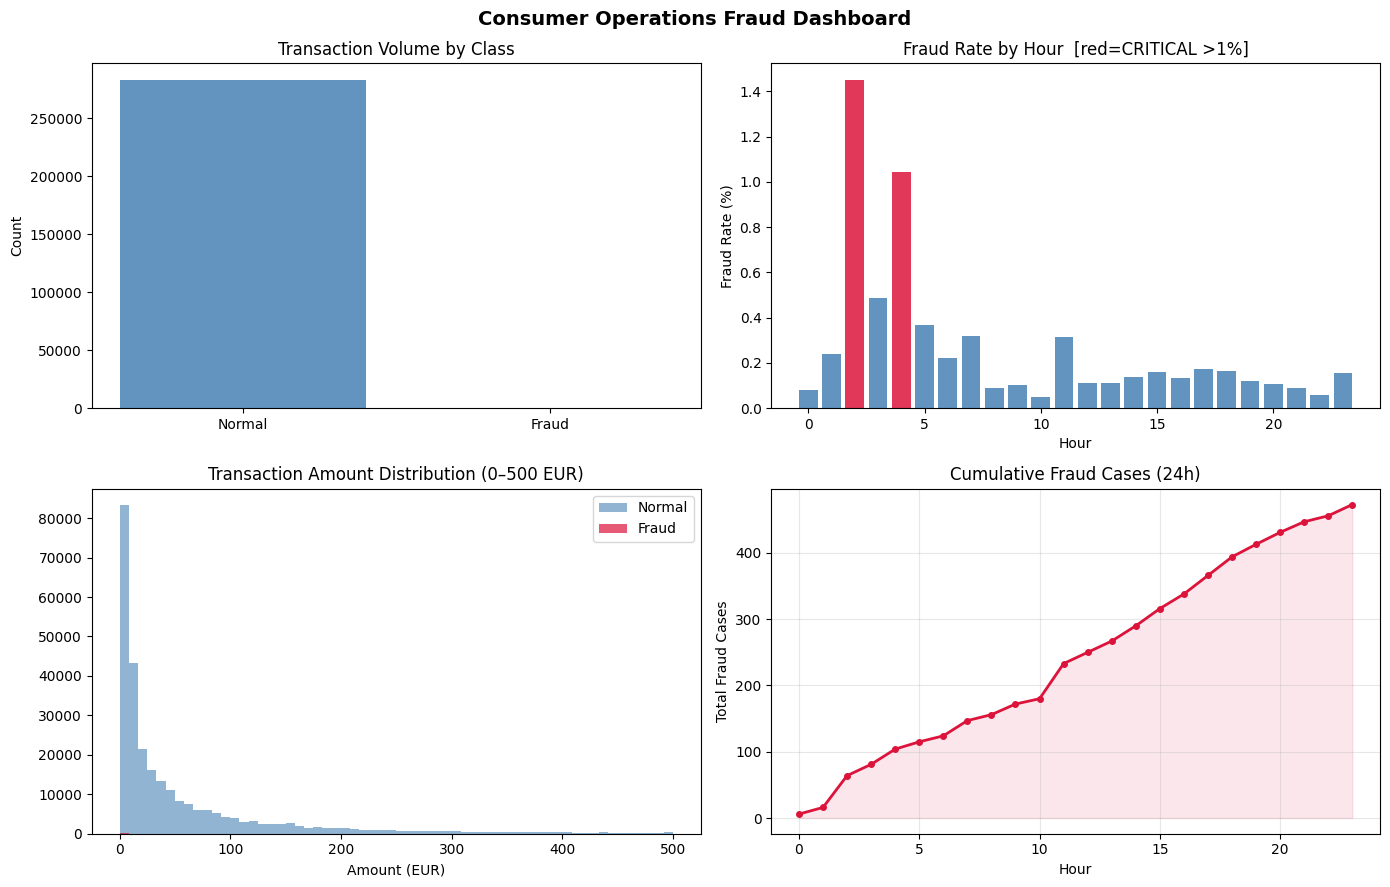

Saved: fraud_dashboard.png


In [35]:
fraud  = df_clean[df_clean['Class'] == 1]
normal = df_clean[df_clean['Class'] == 0]
hourly = df_clean.groupby('hour').agg(total=('Class','count'), fraud=('Class','sum')).reset_index()
hourly['fraud_rate']       = hourly['fraud'] / hourly['total'] * 100
hourly['cumulative_fraud'] = hourly['fraud'].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Consumer Operations Fraud Dashboard', fontsize=14, fontweight='bold')

# Panel 1: Volume
axes[0,0].bar(['Normal', 'Fraud'], [len(normal), len(fraud)],
               color=['steelblue', 'crimson'], alpha=0.85)
axes[0,0].set_title('Transaction Volume by Class')
axes[0,0].set_ylabel('Count')

# Panel 2: Hourly fraud rate
colors = ['crimson' if r > 1.0 else 'orange' if r > 0.5 else 'steelblue'
          for r in hourly['fraud_rate']]
axes[0,1].bar(hourly['hour'], hourly['fraud_rate'], color=colors, alpha=0.85)
axes[0,1].set_title('Fraud Rate by Hour  [red=CRITICAL >1%]')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Fraud Rate (%)')

# Panel 3: Amount distribution
axes[1,0].hist(normal['Amount'], bins=60, range=(0,500),
               alpha=0.6, color='steelblue', label='Normal')
axes[1,0].hist(fraud['Amount'],  bins=60, range=(0,500),
               alpha=0.7, color='crimson',   label='Fraud')
axes[1,0].set_title('Transaction Amount Distribution (0–500 EUR)')
axes[1,0].set_xlabel('Amount (EUR)')
axes[1,0].legend()

# Panel 4: Cumulative fraud
axes[1,1].plot(hourly['hour'], hourly['cumulative_fraud'],
               color='crimson', linewidth=2, marker='o', markersize=4)
axes[1,1].fill_between(hourly['hour'], hourly['cumulative_fraud'],
                        alpha=0.1, color='crimson')
axes[1,1].set_title('Cumulative Fraud Cases (24h)')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Total Fraud Cases')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fraud_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: fraud_dashboard.png')

## Summary

| Skill | Demonstrated |
|-------|--------------|
| Python pipeline | `load_and_clean()` — automated ingestion & deduplication |
| Anomaly detection | `detect_anomalies()` — IQR + time + behavioral features |
| Alerting | `check_alerts()` — threshold-based operational alerts |
| KPI reporting | `generate_kpi_report()` — daily ops metrics |
| SQL basics | SELECT, WHERE, GROUP BY, ORDER BY, aggregations |
| SQL intermediate | HAVING, CASE WHEN, Subqueries, JOIN |
| SQL advanced | CTE (WITH), Window functions: LAG, SUM OVER, ROW_NUMBER |
| Visualization | 4-panel matplotlib dashboard |

---
*Angel Chiang — IMT Atlantique M2 IT & Cybersécurité | Stage 6 mois — Juin 2026*

In [38]:
import requests

webhook_url = "https://angelchiang00.app.n8n.cloud/webhook-test/dadec095-ca58-4408-8d4b-3f054175e0c8"

def send_fraud_alert_to_n8n(alert_type, value):
    """
    API integration: Python → n8n webhook → operations notification
    """
    payload = {
        "alert": alert_type,
        "value": value,
        "message": f"FRAUD ALERT: {alert_type} — {value}",
        "action": "Notify Trust & Safety team immediately"
    }
    response = requests.post(webhook_url, json=payload)
    print(f"Alert sent to n8n | Status: {response.status_code}")
    print(f"→ n8n workflow triggered: notification sent to ops team")
    return response

# Test
send_fraud_alert_to_n8n("HIGH_VALUE_SPIKE", "2935 transactions")

Alert sent to n8n | Status: 200
→ n8n workflow triggered: notification sent to ops team


<Response [200]>

In [37]:
# Export summary tables for Looker Studio
from google.colab import files

# Hourly fraud summary
hourly_export = df_clean.groupby('hour').agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).reset_index()
hourly_export['fraud_rate'] = (hourly_export['fraud'] / hourly_export['total'] * 100).round(3)
hourly_export.to_csv('hourly_fraud.csv', index=False)
files.download('hourly_fraud.csv')

# Segment fraud summary
df_clean['segment'] = pd.cut(
    df_clean['Amount'],
    bins=[-1, 0, 10, 50, 200, 1000, float('inf')],
    labels=['Zero', 'Micro', 'Small', 'Medium', 'Large', 'XLarge']
)
seg_export = df_clean.groupby('segment').agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).reset_index()
seg_export['fraud_rate'] = (seg_export['fraud'] / seg_export['total'] * 100).round(3)
seg_export.to_csv('segment_fraud.csv', index=False)
files.download('segment_fraud.csv')

print('Both files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both files downloaded!
